#### Data

In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   -------------------------------

In [3]:
import yfinance as yf

symbols = ["NVDA", "MSFT", "AMD", "^IXIC"]

data = yf.download(
    symbols,
    start="2018-01-01",
    end="2026-05-31",
    auto_adjust=True
)

data.to_csv("ai_stocks_raw.csv")

[*********************100%***********************]  4 of 4 completed


#### Imports and setup

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# File paths
RAW_PATH = Path("../data/ai_stocks_raw.csv")
OUTPUT_DIR = Path("../reports/data_cleaning_visualization")
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

#### Load the raw dataset and flatten the header

In [3]:
# The file has a 2-row header:
# Row 1 -> OHLCV fields (Close, High, Low, Open, Volume)
# Row 2 -> ticker names (AMD, MSFT, NVDA, ^IXIC)

df_raw = pd.read_csv(RAW_PATH, header=[0, 1])

# Flatten multi-index columns into simple names like AMD_Close, MSFT_Volume, etc.
df_raw.columns = ["Date"] + [f"{ticker}_{field}" for field, ticker in df_raw.columns[1:]]

# Convert Date
df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce")

# Sort and reset index
df_raw = df_raw.sort_values("Date").reset_index(drop=True)

print("Shape:", df_raw.shape)
print(df_raw.head())

Shape: (2109, 21)
        Date  AMD_Close  MSFT_Close  NVDA_Close  ^IXIC_Close  AMD_High  \
0 2018-01-02      10.98   78.699905    4.928265  7006.899902     11.02   
1 2018-01-03      11.55   79.066162    5.252614  7065.529785     12.14   
2 2018-01-04      12.12   79.762062    5.280303  7077.910156     12.43   
3 2018-01-05      11.88   80.750946    5.325050  7136.560059     12.22   
4 2018-01-08      12.28   80.833359    5.488214  7157.390137     12.30   

   MSFT_High  NVDA_High   ^IXIC_High  AMD_Low  ...  NVDA_Low    ^IXIC_Low  \
0  79.029539   4.931973  7006.910156    10.34  ...  4.808365  6924.080078   
1  79.212669   5.283022  7069.149902    11.36  ...  5.037042  7016.700195   
2  80.265671   5.390561  7098.049805    11.97  ...  5.258053  7072.379883   
3  80.952390   5.362380  7137.040039    11.66  ...  5.218252  7097.080078   
4  81.108056   5.562378  7161.350098    11.85  ...  5.403665  7124.089844   

   AMD_Open  MSFT_Open  NVDA_Open   ^IXIC_Open  AMD_Volume  MSFT_Volume  \

#### Basic data quality check

In [4]:
print("Missing values per column:\n", df_raw.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nDate range:", df_raw["Date"].min(), "to", df_raw["Date"].max())

Missing values per column:
 Date           0
AMD_Close      0
MSFT_Close     0
NVDA_Close     0
^IXIC_Close    0
AMD_High       0
MSFT_High      0
NVDA_High      0
^IXIC_High     0
AMD_Low        0
dtype: int64

Duplicate rows: 0

Date range: 2018-01-02 00:00:00 to 2026-05-22 00:00:00


#### Convert numeric columns, remove duplicates, and handle missing values

In [5]:
df = df_raw.copy()

# Convert all non-Date columns to numeric
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove duplicate dates if any
df = df.drop_duplicates(subset=["Date"]).reset_index(drop=True)

# Handle missing values in time-series style:
# 1) linear interpolation
# 2) forward fill
# 3) backward fill
numeric_cols = [c for c in df.columns if c != "Date"]
df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")
df[numeric_cols] = df[numeric_cols].ffill().bfill()

print("After cleaning:")
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
print(df.head())

After cleaning:
Missing values: 0
Duplicates: 0
        Date  AMD_Close  MSFT_Close  NVDA_Close  ^IXIC_Close  AMD_High  \
0 2018-01-02      10.98   78.699905    4.928265  7006.899902     11.02   
1 2018-01-03      11.55   79.066162    5.252614  7065.529785     12.14   
2 2018-01-04      12.12   79.762062    5.280303  7077.910156     12.43   
3 2018-01-05      11.88   80.750946    5.325050  7136.560059     12.22   
4 2018-01-08      12.28   80.833359    5.488214  7157.390137     12.30   

   MSFT_High  NVDA_High   ^IXIC_High  AMD_Low  ...  NVDA_Low    ^IXIC_Low  \
0  79.029539   4.931973  7006.910156    10.34  ...  4.808365  6924.080078   
1  79.212669   5.283022  7069.149902    11.36  ...  5.037042  7016.700195   
2  80.265671   5.390561  7098.049805    11.97  ...  5.258053  7072.379883   
3  80.952390   5.362380  7137.040039    11.66  ...  5.218252  7097.080078   
4  81.108056   5.562378  7161.350098    11.85  ...  5.403665  7124.089844   

   AMD_Open  MSFT_Open  NVDA_Open   ^IXIC_Op

#### Feature engineering for visualization and outlier handling

In [6]:
cleaned = df.copy()

# Extract ticker names automatically
tickers = sorted({c.split("_")[0] for c in cleaned.columns if c != "Date"})

def iqr_cap(series: pd.Series) -> pd.Series:
    """Cap outliers using the IQR method."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

for t in tickers:
    close_col = f"{t}_Close"
    volume_col = f"{t}_Volume"

    # Daily return
    cleaned[f"{t}_Return"] = cleaned[close_col].pct_change()

    # Log return
    cleaned[f"{t}_LogReturn"] = np.log(cleaned[close_col]).diff()

    # Normalized close price (first day = 100)
    cleaned[f"{t}_NormClose"] = cleaned[close_col] / cleaned[close_col].iloc[0] * 100

    # Moving averages
    cleaned[f"{t}_MA20"] = cleaned[close_col].rolling(window=20).mean()
    cleaned[f"{t}_MA50"] = cleaned[close_col].rolling(window=50).mean()

    # Rolling volatility (annualized)
    cleaned[f"{t}_Volatility20"] = cleaned[f"{t}_Return"].rolling(window=20).std() * np.sqrt(252)

    # Outlier handling for return and volume visualizations
    cleaned[f"{t}_Return_Capped"] = iqr_cap(cleaned[f"{t}_Return"])
    cleaned[f"{t}_Volume_Capped"] = iqr_cap(cleaned[volume_col])

print("Tickers found:", tickers)
print(cleaned[[ "Date"] + [f"{t}_Close" for t in tickers]].head())

Tickers found: ['AMD', 'MSFT', 'NVDA', '^IXIC']
        Date  AMD_Close  MSFT_Close  NVDA_Close  ^IXIC_Close
0 2018-01-02      10.98   78.699905    4.928265  7006.899902
1 2018-01-03      11.55   79.066162    5.252614  7065.529785
2 2018-01-04      12.12   79.762062    5.280303  7077.910156
3 2018-01-05      11.88   80.750946    5.325050  7136.560059
4 2018-01-08      12.28   80.833359    5.488214  7157.390137


#### Summary statistics

In [7]:
# Save summary stats for report
summary_stats = cleaned.describe(include="all").transpose()
summary_stats.to_csv(OUTPUT_DIR / "summary_stats_task1.csv")

# Optional: a compact price summary
price_summary = pd.DataFrame({
    "Ticker": tickers,
    "Start_Close": [cleaned[f"{t}_Close"].iloc[0] for t in tickers],
    "End_Close": [cleaned[f"{t}_Close"].iloc[-1] for t in tickers],
    "Min_Close": [cleaned[f"{t}_Close"].min() for t in tickers],
    "Max_Close": [cleaned[f"{t}_Close"].max() for t in tickers],
    "Average_Volume": [cleaned[f"{t}_Volume"].mean() for t in tickers],
})
price_summary.to_csv(OUTPUT_DIR / "price_summary_task1.csv", index=False)

print(price_summary)

  Ticker  Start_Close     End_Close    Min_Close     Max_Close  Average_Volume
0    AMD    10.980000    467.510010     9.530000    467.510010    6.357161e+07
1   MSFT    78.699905    418.570007    77.839203    538.658569    2.804981e+07
2   NVDA     4.928265    215.330002     3.150397    235.740005    4.203605e+08
3  ^IXIC  7006.899902  26343.970703  6192.919922  26635.220703    5.002703e+09


#### Visualization 1: closing price trend

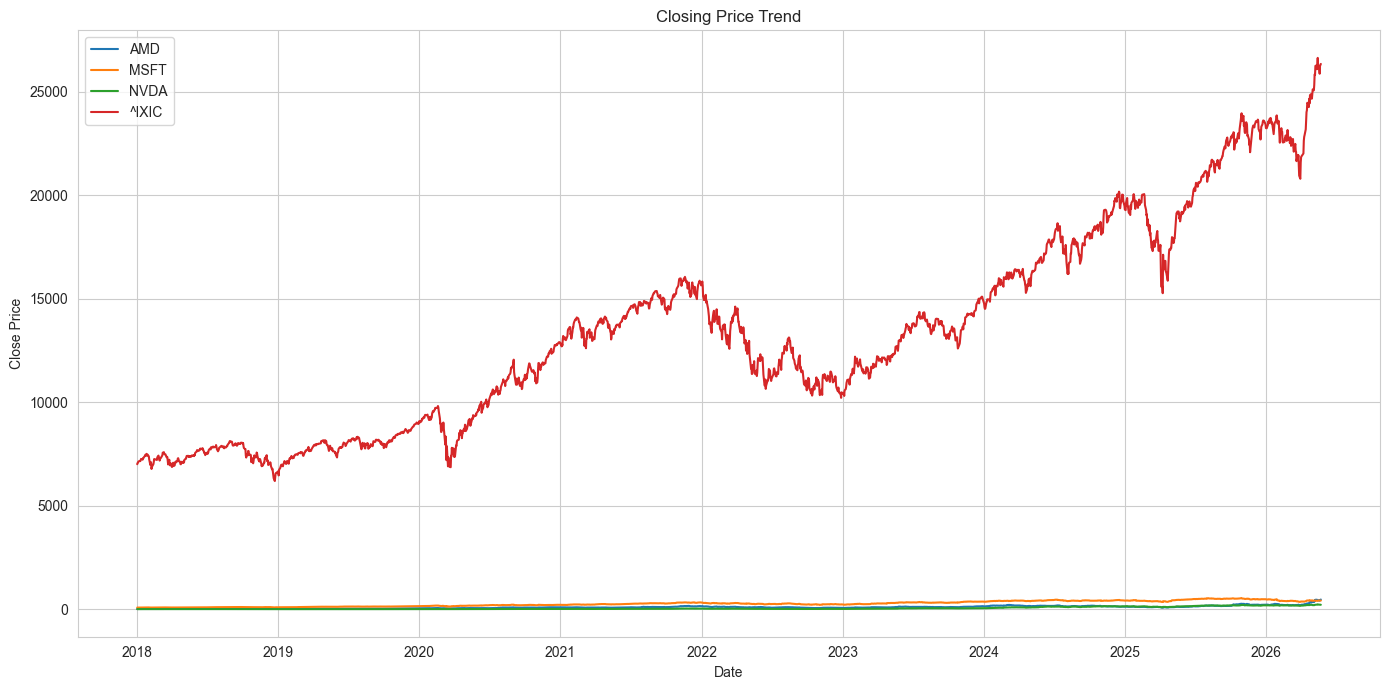

In [8]:
plt.figure(figsize=(14, 7))

for t in tickers:
    plt.plot(cleaned["Date"], cleaned[f"{t}_Close"], label=t)

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_close_price_trend.png", dpi=200)
plt.show()

#### Visualization 2: normalized price comparison

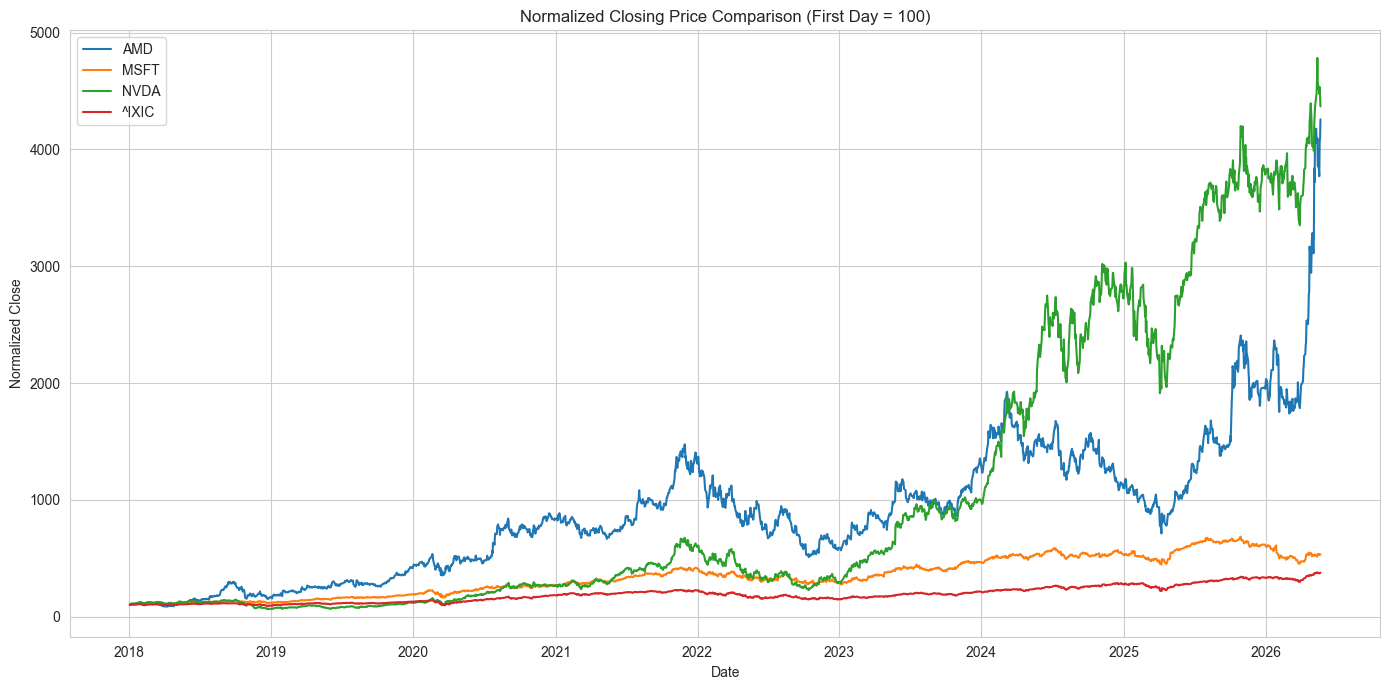

In [9]:
plt.figure(figsize=(14, 7))

for t in tickers:
    plt.plot(cleaned["Date"], cleaned[f"{t}_NormClose"], label=t)

plt.title("Normalized Closing Price Comparison (First Day = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Close")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_normalized_close.png", dpi=200)
plt.show()

#### Visualization 3: rolling moving averages for each stock

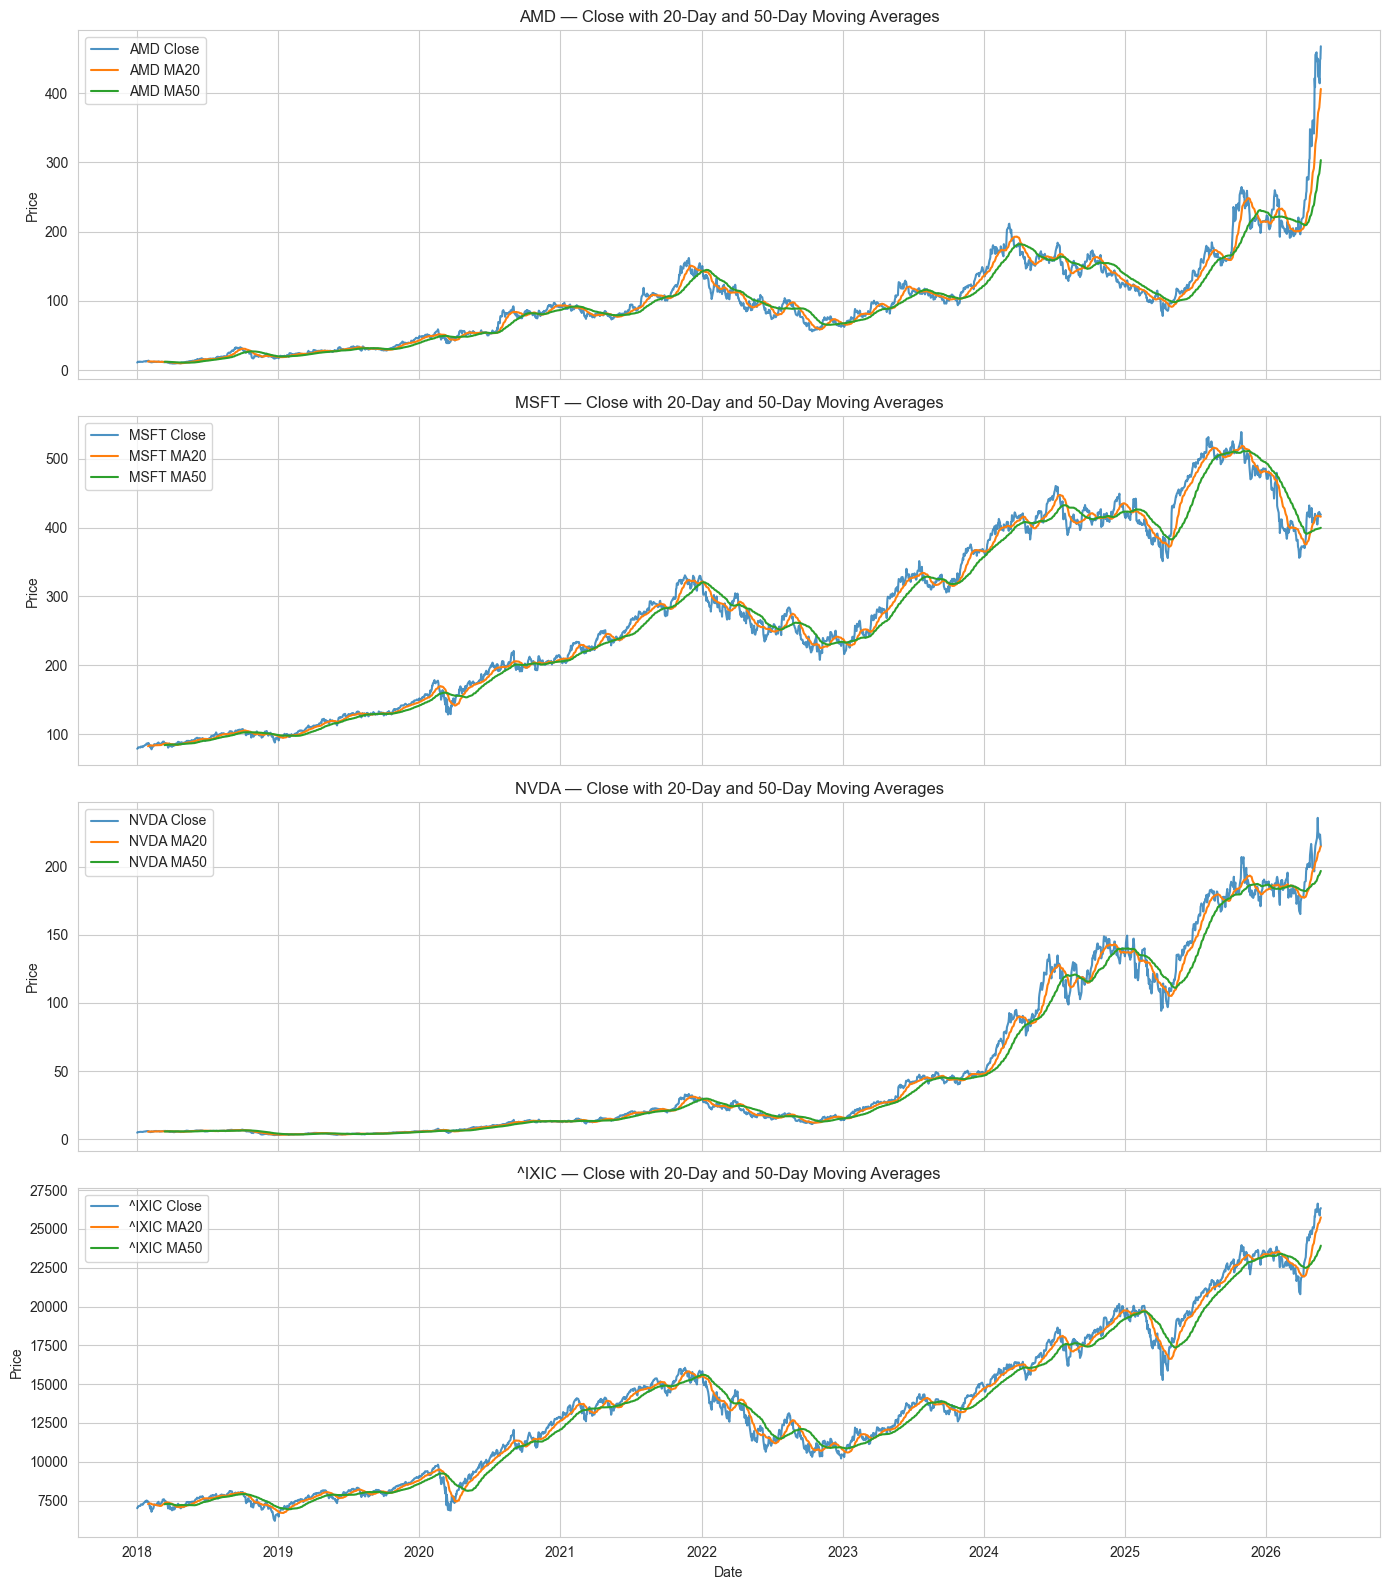

In [10]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, t in zip(axes, tickers):
    ax.plot(cleaned["Date"], cleaned[f"{t}_Close"], label=f"{t} Close", alpha=0.8)
    ax.plot(cleaned["Date"], cleaned[f"{t}_MA20"], label=f"{t} MA20")
    ax.plot(cleaned["Date"], cleaned[f"{t}_MA50"], label=f"{t} MA50")
    ax.set_title(f"{t} — Close with 20-Day and 50-Day Moving Averages")
    ax.set_ylabel("Price")
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_moving_averages.png", dpi=200)
plt.show()

#### Visualization 4: daily return distributions

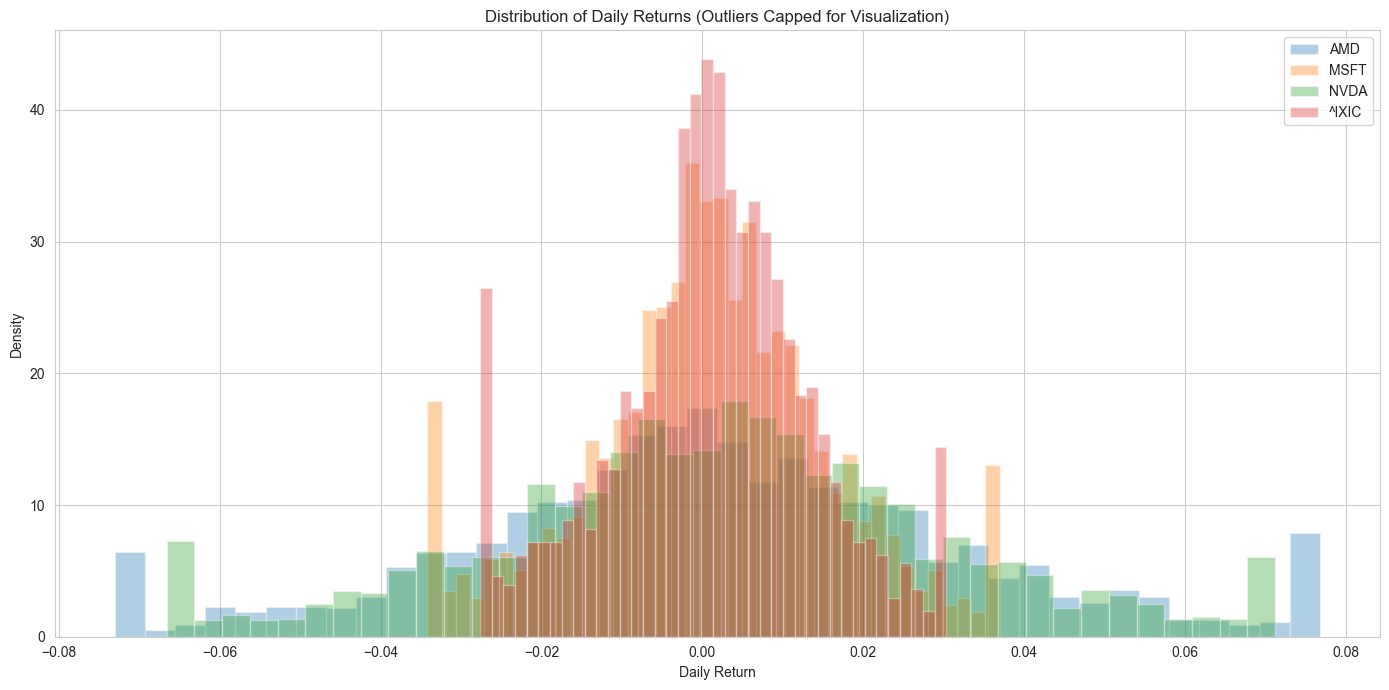

In [11]:
plt.figure(figsize=(14, 7))

for t in tickers:
    plt.hist(
        cleaned[f"{t}_Return_Capped"].dropna(),
        bins=40,
        alpha=0.35,
        density=True,
        label=t
    )

plt.title("Distribution of Daily Returns (Outliers Capped for Visualization)")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_return_distribution.png", dpi=200)
plt.show()

#### Visualization 5: trading volume trend

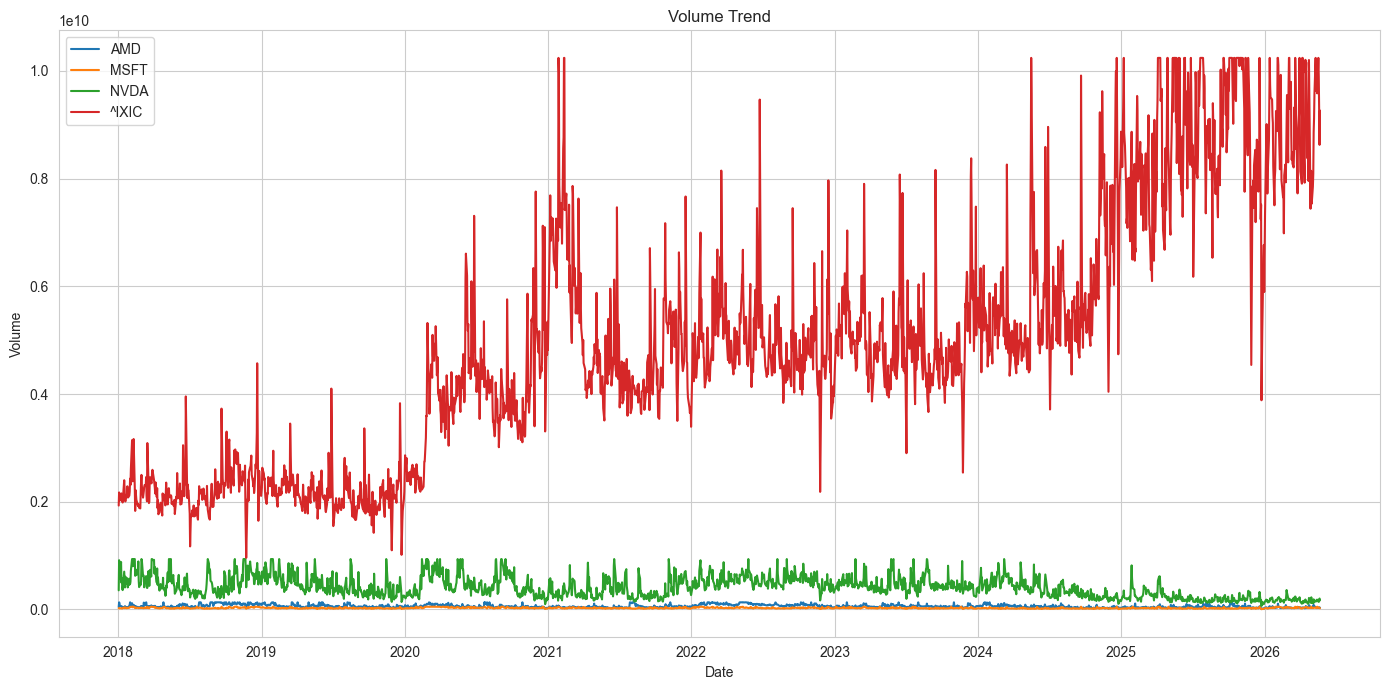

In [12]:
plt.figure(figsize=(14, 7))

for t in tickers:
    plt.plot(cleaned["Date"], cleaned[f"{t}_Volume_Capped"], label=t)

plt.title("Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_volume_trend.png", dpi=200)
plt.show()

#### Visualization 6: correlation heatmap of returns

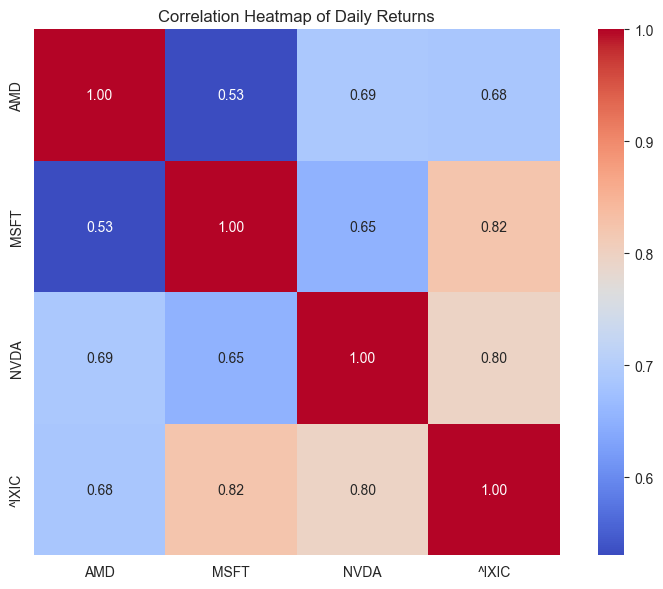

In [13]:
return_df = pd.DataFrame({
    t: cleaned[f"{t}_Return_Capped"] for t in tickers
})

plt.figure(figsize=(8, 6))
sns.heatmap(return_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Daily Returns")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_return_correlation_heatmap.png", dpi=200)
plt.show()

#### Visualization 7: rolling volatility comparison

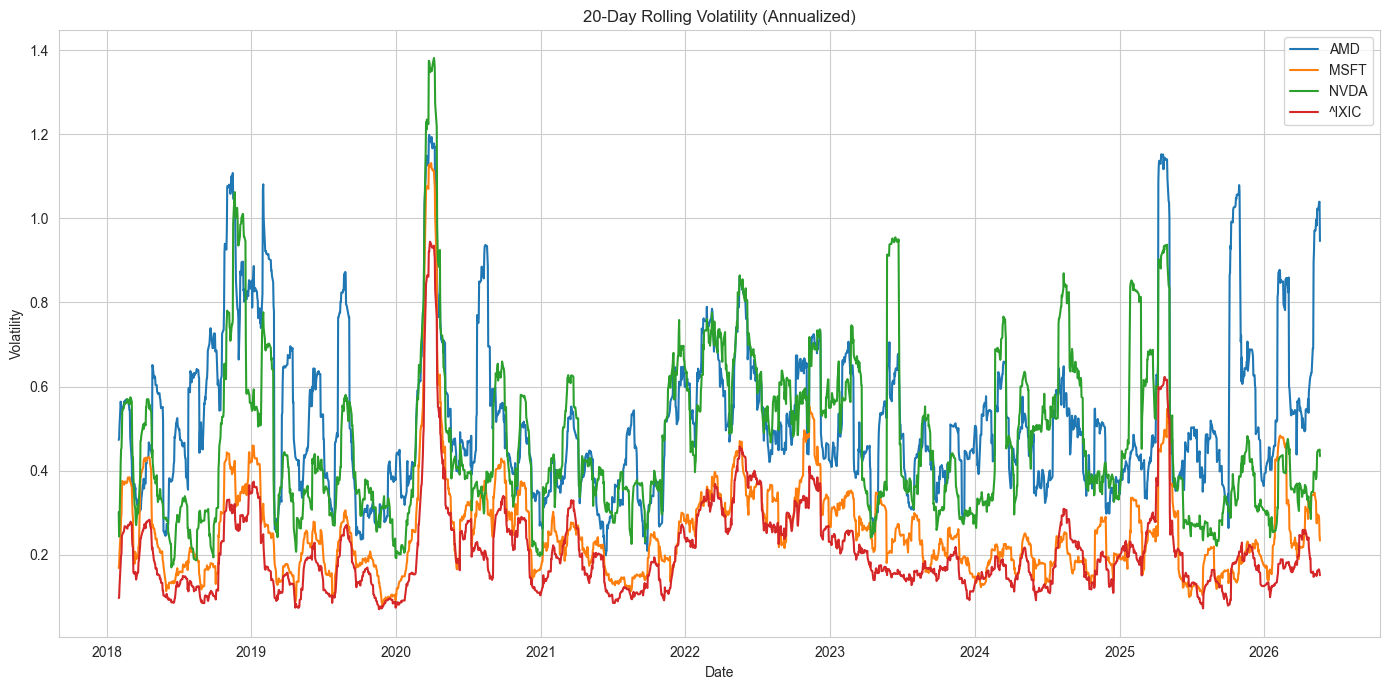

In [14]:
plt.figure(figsize=(14, 7))

for t in tickers:
    plt.plot(cleaned["Date"], cleaned[f"{t}_Volatility20"], label=t)

plt.title("20-Day Rolling Volatility (Annualized)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_rolling_volatility.png", dpi=200)
plt.show()

#### One dashboard-style figure

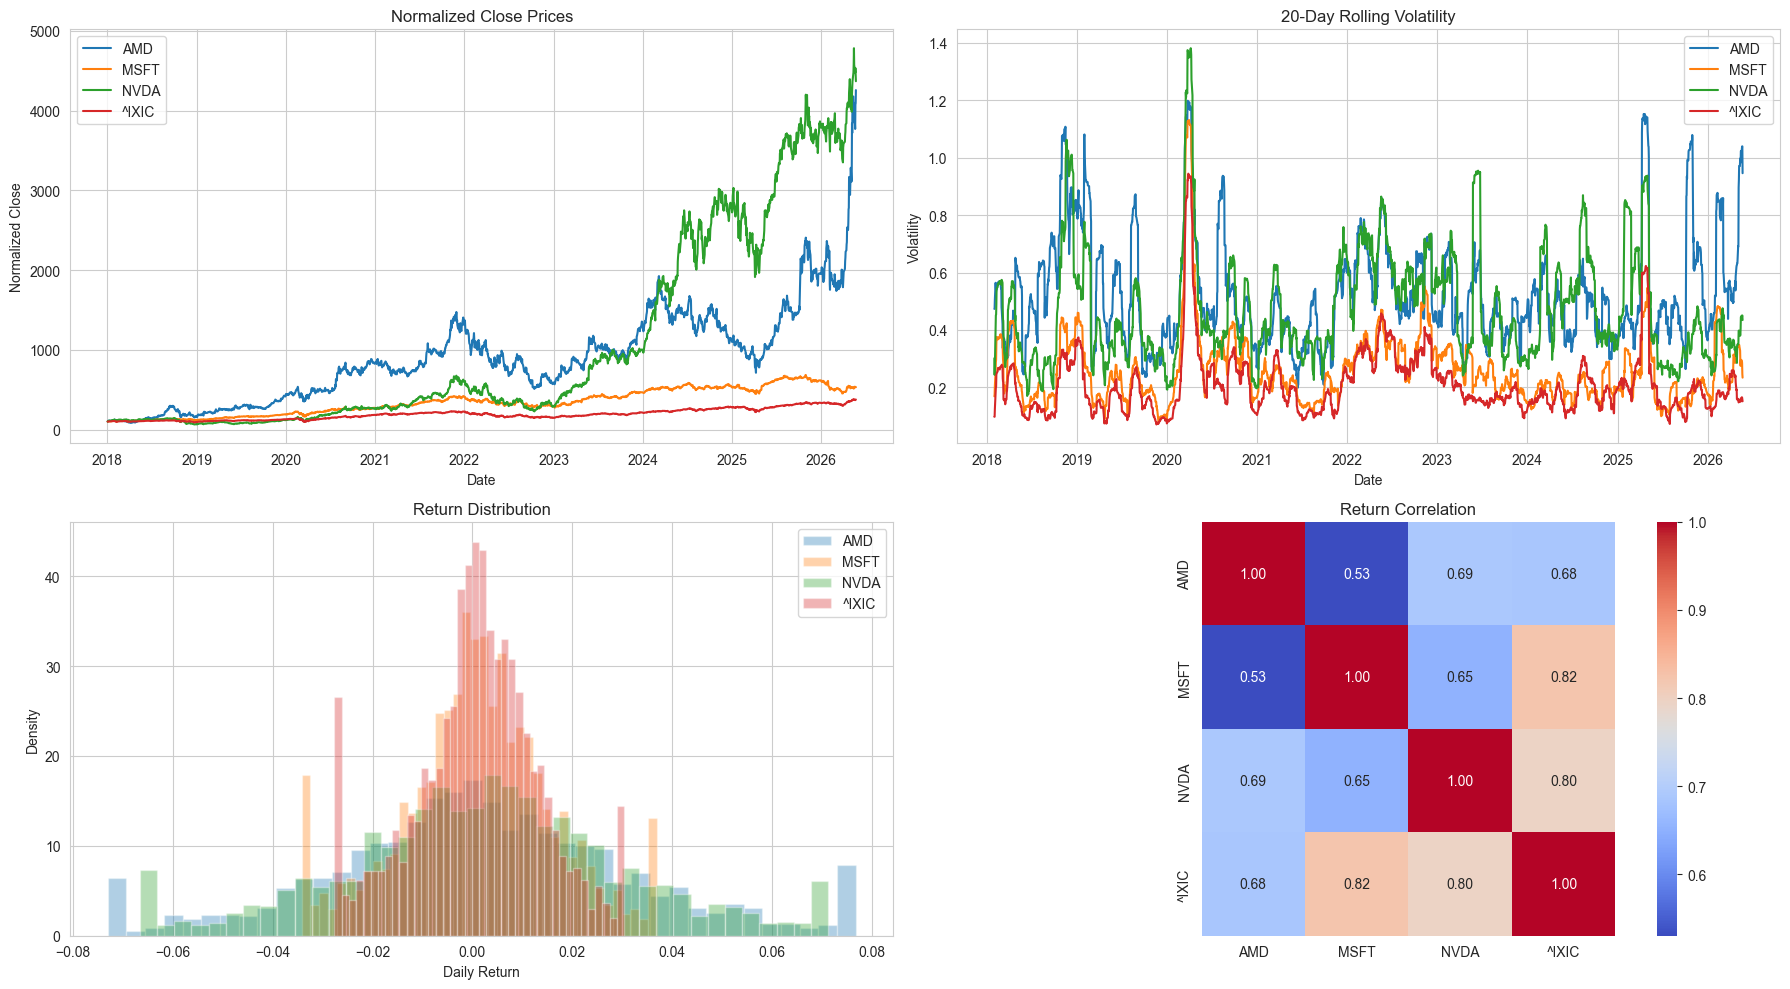

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1) Normalized price
for t in tickers:
    axes[0, 0].plot(cleaned["Date"], cleaned[f"{t}_NormClose"], label=t)
axes[0, 0].set_title("Normalized Close Prices")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Normalized Close")
axes[0, 0].legend()

# 2) Volatility
for t in tickers:
    axes[0, 1].plot(cleaned["Date"], cleaned[f"{t}_Volatility20"], label=t)
axes[0, 1].set_title("20-Day Rolling Volatility")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Volatility")
axes[0, 1].legend()

# 3) Return distribution
for t in tickers:
    axes[1, 0].hist(
        cleaned[f"{t}_Return_Capped"].dropna(),
        bins=40,
        alpha=0.35,
        density=True,
        label=t
    )
axes[1, 0].set_title("Return Distribution")
axes[1, 0].set_xlabel("Daily Return")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# 4) Correlation heatmap
sns.heatmap(return_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=axes[1, 1])
axes[1, 1].set_title("Return Correlation")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_dashboard.png", dpi=200)
plt.show()

#### Save the cleaned dataset

In [16]:
cleaned.to_csv("../data/cleaned_ai_stocks_task1.csv", index=False)

print("Cleaned dataset shape:", cleaned.shape)

Cleaned dataset shape: (2109, 53)


#### Final sanity check

In [17]:
print(cleaned.head())
print("\nColumns:", list(cleaned.columns[:15]), "...")
print("\nAny missing values left:", cleaned.isna().sum().sum())

        Date  AMD_Close  MSFT_Close  NVDA_Close  ^IXIC_Close  AMD_High  \
0 2018-01-02      10.98   78.699905    4.928265  7006.899902     11.02   
1 2018-01-03      11.55   79.066162    5.252614  7065.529785     12.14   
2 2018-01-04      12.12   79.762062    5.280303  7077.910156     12.43   
3 2018-01-05      11.88   80.750946    5.325050  7136.560059     12.22   
4 2018-01-08      12.28   80.833359    5.488214  7157.390137     12.30   

   MSFT_High  NVDA_High   ^IXIC_High  AMD_Low  ...  NVDA_Return_Capped  \
0  79.029539   4.931973  7006.910156    10.34  ...                 NaN   
1  79.212669   5.283022  7069.149902    11.36  ...            0.065814   
2  80.265671   5.390561  7098.049805    11.97  ...            0.005271   
3  80.952390   5.362380  7137.040039    11.66  ...            0.008474   
4  81.108056   5.562378  7161.350098    11.85  ...            0.030641   

   NVDA_Volume_Capped  ^IXIC_Return  ^IXIC_LogReturn  ^IXIC_NormClose  \
0           355616000           NaN  